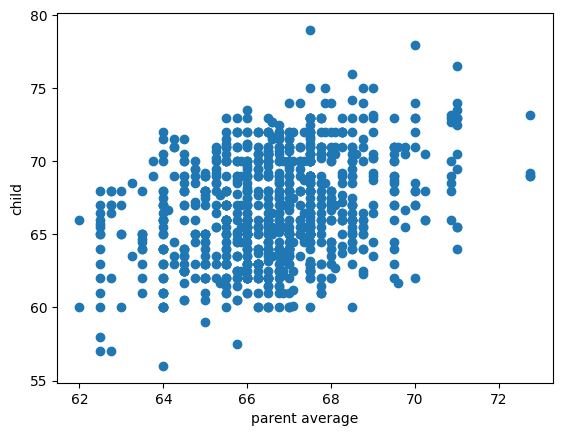

In [12]:
import pandas as pd

import matplotlib.pyplot as plt

df = pd.read_csv("family_heights-1-1.csv")
df.head()

df["parent average"] = (df["father"] + df["mother"]) / 2

plt.scatter(df["parent average"], df["child"])
plt.xlabel("parent average")
plt.ylabel("child")
plt.show()

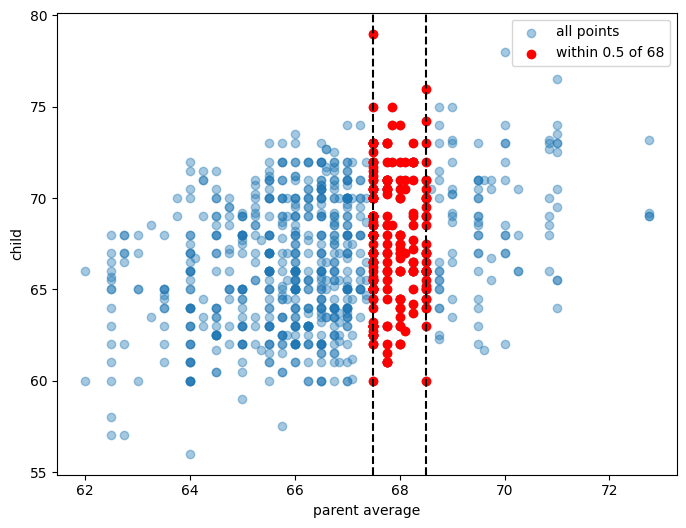

67.614


In [13]:
# highlight points with parent average between 67.5 and 68.5 and plot vertical lines
mask = df["parent average"].between(67.5, 68.5)

plt.figure(figsize=(8,6))
plt.scatter(df["parent average"], df["child"], alpha=0.4, label="all points")
plt.scatter(df.loc[mask, "parent average"], df.loc[mask, "child"], color="red", label="within 0.5 of 68")
plt.axvline(67.5, color="black", linestyle="--")
plt.axvline(68.5, color="black", linestyle="--")
plt.xlabel("parent average")
plt.ylabel("child")
plt.legend()
plt.show()

def predict_child_height(parent_avg, window=0.5):
    sel = df["parent average"].between(parent_avg - window, parent_avg + window)
    vals = df.loc[sel, "child"]
    if vals.empty:
        return None
    return round(vals.mean(), 3)

# prediction for parent average = 68
print(predict_child_height(68))

In [14]:
print(predict_child_height(66))

66.187


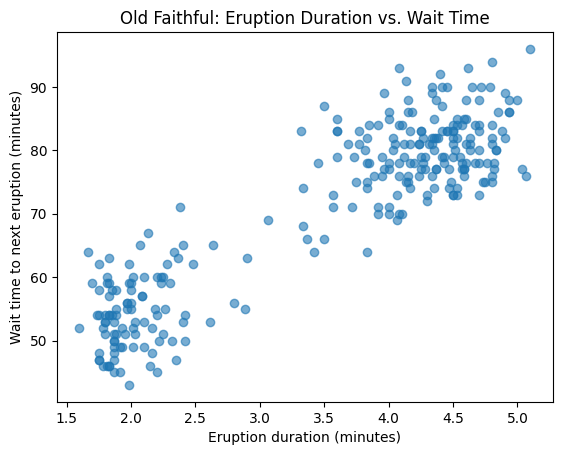

In [15]:
import pandas as pd

import matplotlib.pyplot as plt

faithful = pd.read_csv("faithful-1.csv")

plt.scatter(faithful["duration"], faithful["wait"], alpha=0.6)
plt.xlabel("Eruption duration (minutes)")
plt.ylabel("Wait time to next eruption (minutes)")
plt.title("Old Faithful: Eruption Duration vs. Wait Time")
plt.show()

In [16]:
# Compute means and standard deviations
duration_mean = faithful["duration"].mean()
duration_std = faithful["duration"].std()
wait_mean = faithful["wait"].mean()
wait_std = faithful["wait"].std()

print("Duration mean:", duration_mean, "std:", duration_std)
print("Wait mean:", wait_mean, "std:", wait_std)

# Create table with standard units
faithful_standard = pd.DataFrame({
    "duration (standard units)": (faithful["duration"] - duration_mean) / duration_std,
    "wait (standard units)": (faithful["wait"] - wait_mean) / wait_std
})

faithful_standard.head()

Duration mean: 3.4877830882352936 std: 1.141371251105208
Wait mean: 70.8970588235294 std: 13.594973789999397


,duration (standard units),wait (standard units)
0,0.098318,0.596025
1,-1.478733,-1.242890
2,-0.135612,0.228242
3,-1.055558,-0.654437
4,0.915755,1.037364


In [17]:
# Compute the correlation coefficient r between duration and wait
r = faithful["duration"].corr(faithful["wait"])
print("Correlation coefficient r:", round(r, 3))

Correlation coefficient r: 0.901


In [18]:
# Regression line: wait = slope * duration + y_intercept
slope = r * (wait_std / duration_std)
y_intercept = wait_mean - slope * duration_mean

print("Slope is about", slope)
print("y-int is about", y_intercept)

Slope is about 10.729641395133523
y-int is about 33.474397022753365


In [19]:
# Use regression line: wait = slope * duration + y_intercept
predicted_wait_2min = (slope * 2 + y_intercept)
predicted_wait_5min = (slope * 5 + y_intercept)

print("Predicted wait for 2 min eruption:", predicted_wait_2min)
print("Predicted wait for 5 min eruption:", predicted_wait_5min)

Predicted wait for 2 min eruption: 54.93367981302041
Predicted wait for 5 min eruption: 87.12260399842098


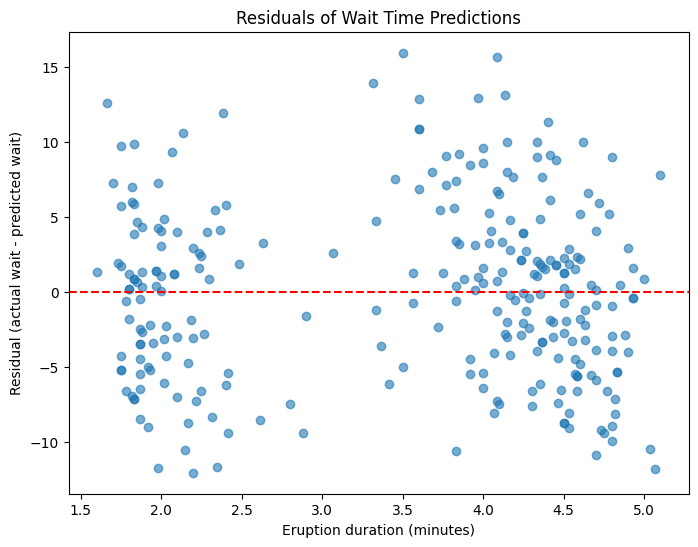

In [20]:
# Make predictions for each eruption in the faithful table
faithful_predictions = faithful.copy()
faithful_predictions["predicted_wait"] = slope * faithful_predictions["duration"] + y_intercept

# Compute residuals: actual wait - predicted wait
faithful_residuals = faithful_predictions.copy()
faithful_residuals["residual"] = faithful_residuals["wait"] - faithful_residuals["predicted_wait"]

# Plot the residuals
plt.figure(figsize=(8,6))
plt.scatter(faithful_residuals["duration"], faithful_residuals["residual"], alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Eruption duration (minutes)")
plt.ylabel("Residual (actual wait - predicted wait)")
plt.title("Residuals of Wait Time Predictions")
plt.show()

In [ ]:
def correlation_coefficient(x, y):
    x_mean = x.mean()
    y_mean = y.mean()
    numerator = ((x - x_mean) * (y - y_mean)).sum()
    denominator = (( (x - x_mean)**2 ).sum() * ( (y - y_mean)**2 ).sum()) ** 0.5
    return numerator / denominator